# N$_2$O modelling pipeline for WWTP operational data

This notebook implements a full end-to-end modelling workflow for the wastewater treatment plant $N_2O$ project. It is designed around the project brief and report structure:

- continuous prediction of $N_2O$ concentration,
- prediction of high-$N_2O$ threshold breaches,
- optional sequence modelling with a neural network,
- exploratory phase/regime analysis to investigate changing system behaviour.

The notebook uses the seven selected predictors:

- `t1_nh4`
- `t1_no3`
- `t1_airflow`
- `t1_temp`
- `t1_ss`
- `t1_po4`
- `inflow`

## 1. Imports and configuration

The code below imports the required libraries, defines the candidate file paths, and sets the modelling configuration. The notebook assumes the data are at 10-minute resolution, so lag windows of 10 minutes to 2 hours are represented using 1, 3, 6, and 12 timesteps.


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

RANDOM_STATE = 42

candidate_paths = [
    Path("df_10T.csv"),
    Path(r"C:\Users\tomor\Documents\MSc Lecture Notes\Data Science Project\EDS_Design_Project\data\EDA\df_10T.csv"),
]

features = [
    "t1_nh4",
    "t1_no3",
    "t1_airflow",
    "t1_temp",
    "t1_ss",
    "t1_po4",
    "inflow",
]

LAGS = [1, 3, 6, 12]          # 10 min, 30 min, 60 min, 120 min
ROLL_WINDOWS = [3, 6, 12]     # 30 min, 60 min, 120 min
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9


## 2. Utility functions

These functions handle data loading, timestamp detection, feature engineering, temporal splitting, and model evaluation.


In [8]:

def find_existing_path(paths):
    for path in paths:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Could not find the dataset in any candidate path. "
        "Please place the notebook in the correct folder or update `candidate_paths`."
    )

def detect_target_column(df):
    candidates = ["t1_n2o", "n2o", "N2O", "t1_N2O"]
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(
        "Could not identify the N2O target column. "
        "Expected one of: 't1_n2o', 'n2o', 'N2O', 't1_N2O'."
    )

def detect_time_column(df):
    explicit_candidates = [
        "timestamp", "time", "datetime", "date_time", "DateTime", "Timestamp", "Time"
    ]
    for col in explicit_candidates:
        if col in df.columns:
            parsed = pd.to_datetime(df[col], errors="coerce")
            if parsed.notna().mean() > 0.8:
                return col
    for col in df.columns:
        if df[col].dtype == "object":
            parsed = pd.to_datetime(df[col], errors="coerce")
            if parsed.notna().mean() > 0.8:
                return col
    return None

def make_time_features(df, dt_col):
    out = df.copy()
    if dt_col is None:
        return out

    out["hour"] = out[dt_col].dt.hour
    out["dayofweek"] = out[dt_col].dt.dayofweek
    out["month"] = out[dt_col].dt.month

    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)
    return out

def engineer_features(df, base_features, target_col):
    out = df.copy()

    # Past target values are allowed for forecasting because they are lagged
    lag_base = base_features + [target_col]

    for col in lag_base:
        for lag in LAGS:
            out[f"{col}_lag_{lag}"] = out[col].shift(lag)

    # Rolling summaries use only past information via shift(1)
    for col in base_features:
        shifted = out[col].shift(1)
        for window in ROLL_WINDOWS:
            out[f"{col}_rollmean_{window}"] = shifted.rolling(window).mean()
            out[f"{col}_rollstd_{window}"] = shifted.rolling(window).std()

    # A few simple interaction terms motivated by process understanding
    if {"t1_nh4", "t1_airflow"}.issubset(out.columns):
        out["nh4_x_airflow"] = out["t1_nh4"] * out["t1_airflow"]
    if {"t1_no3", "inflow"}.issubset(out.columns):
        out["no3_x_inflow"] = out["t1_no3"] * out["inflow"]
    if {"t1_temp", "t1_airflow"}.issubset(out.columns):
        out["temp_x_airflow"] = out["t1_temp"] * out["t1_airflow"]

    return out

def temporal_split(df, train_frac=0.70, val_frac=0.15, test_frac=0.15):
    n = len(df)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    train = df.iloc[:train_end].copy()
    val = df.iloc[train_end:val_end].copy()
    test = df.iloc[val_end:].copy()

    return train, val, test

def regression_metrics(y_true, y_pred):
    # Compatible with both older and newer scikit-learn versions
    try:
        rmse = mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "RMSE": rmse,
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

def classification_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    # ROC AUC and PR AUC require both classes to be present
    if len(np.unique(y_true)) == 2:
        metrics["ROC_AUC"] = roc_auc_score(y_true, y_prob)
        metrics["PR_AUC"] = average_precision_score(y_true, y_prob)
    else:
        metrics["ROC_AUC"] = np.nan
        metrics["PR_AUC"] = np.nan
    return metrics

def get_probabilities(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return 1 / (1 + np.exp(-scores))
    raise AttributeError("Model does not support probability-style outputs.")

def fit_and_score_regression_models(model_dict, X_train, y_train, X_val, y_val, X_test, y_test):
    fitted_models = {}
    rows = []
    for name, model in model_dict.items():
        fitted = clone(model)
        fitted.fit(X_train, y_train)

        train_pred = fitted.predict(X_train)
        val_pred = fitted.predict(X_val)
        test_pred = fitted.predict(X_test)

        row = {"Model": name}
        row.update({f"Train_{k}": v for k, v in regression_metrics(y_train, train_pred).items()})
        row.update({f"Val_{k}": v for k, v in regression_metrics(y_val, val_pred).items()})
        row.update({f"Test_{k}": v for k, v in regression_metrics(y_test, test_pred).items()})
        rows.append(row)
        fitted_models[name] = fitted

    results = pd.DataFrame(rows).sort_values("Val_RMSE").reset_index(drop=True)
    return fitted_models, results

def fit_and_score_classification_models(model_dict, X_train, y_train, X_val, y_val, X_test, y_test):
    fitted_models = {}
    rows = []
    for name, model in model_dict.items():
        fitted = clone(model)
        fitted.fit(X_train, y_train)

        train_prob = get_probabilities(fitted, X_train)
        val_prob = get_probabilities(fitted, X_val)
        test_prob = get_probabilities(fitted, X_test)

        row = {"Model": name}
        row.update({f"Train_{k}": v for k, v in classification_metrics(y_train, train_prob).items()})
        row.update({f"Val_{k}": v for k, v in classification_metrics(y_val, val_prob).items()})
        row.update({f"Test_{k}": v for k, v in classification_metrics(y_test, test_prob).items()})
        rows.append(row)
        fitted_models[name] = fitted

    results = pd.DataFrame(rows).sort_values("Val_PR_AUC", ascending=False).reset_index(drop=True)
    return fitted_models, results

def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.25)
    line_min = min(np.nanmin(y_true), np.nanmin(y_pred))
    line_max = max(np.nanmax(y_true), np.nanmax(y_pred))
    plt.plot([line_min, line_max], [line_min, line_max])
    plt.xlabel("Actual N2O")
    plt.ylabel("Predicted N2O")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_timeseries_prediction(index, y_true, y_pred, title, n_points=1000):
    plt.figure(figsize=(12, 4))
    if len(y_true) > n_points:
        idx = slice(0, n_points)
    else:
        idx = slice(None)
    plt.plot(index[idx], y_true.iloc[idx], label="Actual")
    plt.plot(index[idx], pd.Series(y_pred, index=index).iloc[idx], label="Predicted")
    plt.xlabel("Time")
    plt.ylabel("N2O")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 3. Load the dataset

This section loads the data, identifies the target and timestamp columns, performs minimal sanity checks, and sorts the dataset chronologically.


In [3]:

data_path = find_existing_path(candidate_paths)
df = pd.read_csv(data_path)

target_col = detect_target_column(df)
time_col = detect_time_column(df)

if time_col is not None:
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.sort_values(time_col).reset_index(drop=True)
else:
    print("No timestamp column detected. The notebook will preserve the current row order as temporal order.")

required_cols = features + [target_col]
missing_required = [col for col in required_cols if col not in df.columns]
if missing_required:
    raise KeyError(f"Missing required columns in the dataset: {missing_required}")

df[required_cols] = df[required_cols].apply(pd.to_numeric, errors="coerce")

print(f"Loaded: {data_path}")
print(f"Shape: {df.shape}")
print(f"Target column: {target_col}")
print(f"Time column: {time_col}")
df.head()


Loaded: C:\Users\tomor\Documents\MSc Lecture Notes\Data Science Project\EDS_Design_Project\data\EDA\df_10T.csv
Shape: (105264, 35)
Target column: t1_n2o
Time column: time


,time,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,...,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q
0,2022-06-11 22:00:00+00:00,27927.583984,NaN,0.670255,1.490831,0.399823,0.457755,1.124573,NaN,1.511840,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
1,2022-06-11 22:10:00+00:00,18362.584961,NaN,0.601157,1.644313,0.355465,0.919777,1.101837,NaN,1.496870,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2,2022-06-11 22:20:00+00:00,20433.400391,NaN,0.528009,2.219421,0.346612,0.519459,1.292950,NaN,1.514961,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
3,2022-06-11 22:30:00+00:00,19882.449805,NaN,0.495718,2.272571,0.475687,1.570746,1.296754,NaN,1.481867,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
4,2022-06-11 22:40:00+00:00,12538.500000,NaN,0.517824,2.424297,0.844169,0.922960,1.289009,NaN,1.518550,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0


## 4. Basic cleaning and sanity checks

The project report indicates that preprocessing and resampling have already been carried out. This notebook therefore applies only a light-touch cleaning step before modelling:

- impossible negative values in the selected process variables and target are converted to missing values,
- time-based features are added if a timestamp column is available,
- lagged and rolling features are created using only past information.


In [4]:

clean_df = df.copy()

for col in features + [target_col]:
    clean_df.loc[clean_df[col] < 0, col] = np.nan

if time_col is not None:
    clean_df = make_time_features(clean_df, time_col)

model_df = engineer_features(clean_df, features, target_col)

# Drop rows where the target is missing
model_df = model_df.loc[model_df[target_col].notna()].copy()

# Drop the earliest rows lost to lagging/rolling
model_df = model_df.dropna(subset=[c for c in model_df.columns if c.endswith("_lag_12") or c.endswith("_rollmean_12")]).copy()

print("Rows after cleaning and feature engineering:", len(model_df))
print("Columns after feature engineering:", model_df.shape[1])


Rows after cleaning and feature engineering: 87606
Columns after feature engineering: 119


## 5. Define modelling feature matrix

The final predictor set includes:

- the seven selected process variables,
- lagged values up to 2 hours,
- rolling summaries over 30, 60, and 120 minutes,
- simple time-of-day and day-of-week cyclic features where a timestamp exists,
- a small number of process-motivated interaction terms.

This gives the baseline models enough temporal context without requiring a pure sequence model.


In [5]:

base_cols = features.copy()

time_feature_cols = [col for col in ["hour_sin", "hour_cos", "dow_sin", "dow_cos"] if col in model_df.columns]
lag_cols = [col for col in model_df.columns if "_lag_" in col]
rolling_cols = [col for col in model_df.columns if "_rollmean_" in col or "_rollstd_" in col]
interaction_cols = [col for col in ["nh4_x_airflow", "no3_x_inflow", "temp_x_airflow"] if col in model_df.columns]

feature_cols = base_cols + time_feature_cols + lag_cols + rolling_cols + interaction_cols
feature_cols = list(dict.fromkeys(feature_cols))

final_df = model_df[[time_col] + feature_cols + [target_col]].copy() if time_col else model_df[feature_cols + [target_col]].copy()
final_df = final_df.dropna(subset=[target_col]).copy()

print(f"Number of modelling features: {len(feature_cols)}")
print("First 15 features:")
print(feature_cols[:15])


Number of modelling features: 88
First 15 features:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_ss', 't1_po4', 'inflow', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 't1_nh4_lag_1', 't1_nh4_lag_3', 't1_nh4_lag_6', 't1_nh4_lag_12']


## 6. Temporal train-validation-test split

The split is chronological rather than random, which is essential for time-dependent process data. This avoids leakage from the future into the past and provides a more realistic estimate of how the models would behave in deployment.


In [6]:

train_df, val_df, test_df = temporal_split(final_df, TRAIN_FRAC, VAL_FRAC, TEST_FRAC)

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df[target_col]
y_val = val_df[target_col]
y_test = test_df[target_col]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (61324, 88)
Validation shape: (13141, 88)
Test shape: (13141, 88)


## 7. Regression task: continuous $N_2O$ forecasting

This is the main continuous prediction task. The notebook compares a staged set of models:

- Elastic Net as an interpretable regularised baseline,
- a GAM-style spline model to capture smooth non-linearity,
- Random Forest for non-linear interactions,
- histogram gradient boosting as a strong tabular learner,
- an MLP neural network as the feed-forward neural model.

The spline-based model acts as a practical GAM-style implementation that remains easy to run inside a standard Python workflow.


In [9]:

numeric_features = feature_cols

elastic_net_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        max_iter=20000,
        random_state=RANDOM_STATE
    ))
])

gam_style_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("splines", SplineTransformer(
        n_knots=5,
        degree=3,
        include_bias=False
    )),
    ("model", ElasticNetCV(
        l1_ratio=[0.05, 0.1, 0.3, 0.5],
        alphas=np.logspace(-4, 1, 20),
        cv=5,
        max_iter=20000,
        random_state=RANDOM_STATE
    ))
])

rf_reg_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

hgb_reg_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ))
])

mlp_reg_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

regression_models = {
    "Elastic Net": elastic_net_model,
    "GAM-style Spline Model": gam_style_model,
    "Random Forest Regressor": rf_reg_model,
    "HistGradientBoosting Regressor": hgb_reg_model,
    "MLP Regressor": mlp_reg_model,
}

reg_fitted, reg_results = fit_and_score_regression_models(
    regression_models, X_train, y_train, X_val, y_val, X_test, y_test
)

reg_results


,Model,Train_RMSE,Train_MAE,Train_R2,Val_RMSE,Val_MAE,Val_R2,Test_RMSE,Test_MAE,Test_R2
0,Elastic Net,0.038484,0.020724,0.976343,0.017705,0.012306,0.982672,0.035955,0.021091,0.935730
1,HistGradientBoosting Regressor,0.023389,0.011331,0.991262,0.018969,0.011080,0.980108,0.034889,0.019598,0.939483
2,GAM-style Spline Model,0.038774,0.021511,0.975985,0.019245,0.014037,0.979525,0.034776,0.021052,0.939875
3,Random Forest Regressor,0.014350,0.004700,0.996711,0.019454,0.011914,0.979078,0.034686,0.019124,0.940188
4,MLP Regressor,0.021917,0.012475,0.992327,0.023850,0.017277,0.968554,0.035785,0.023702,0.936337


### Select the best regression model

The best model is selected on validation RMSE. The test set is kept untouched until after that choice.


In [10]:

best_reg_name = reg_results.iloc[0]["Model"]
best_reg_model = reg_fitted[best_reg_name]

print("Best regression model based on validation RMSE:", best_reg_name)

y_test_pred_reg = best_reg_model.predict(X_test)
print(regression_metrics(y_test, y_test_pred_reg))


Best regression model based on validation RMSE: Elastic Net
{'RMSE': np.float64(0.035955125458149016), 'MAE': 0.02109105829324318, 'R2': 0.9357297113060296}


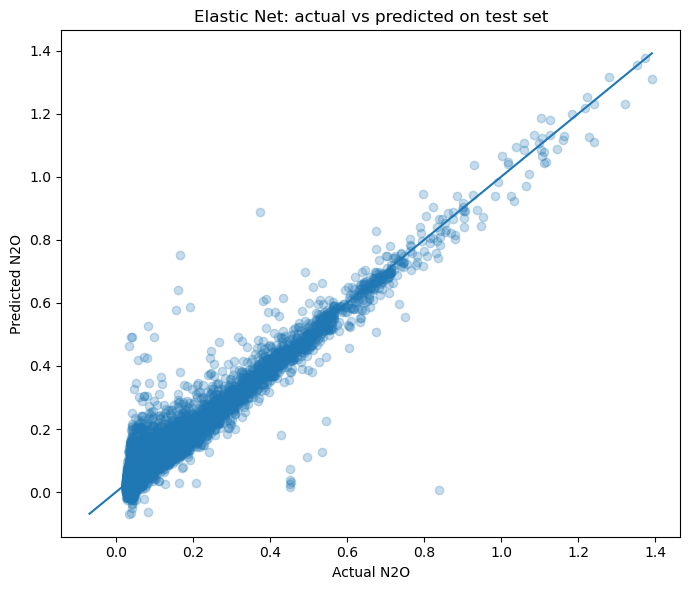

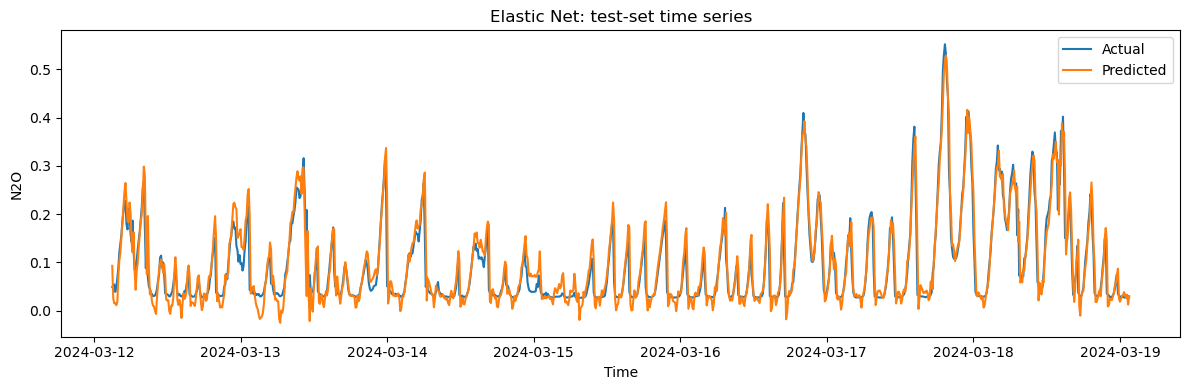

In [11]:

plot_actual_vs_predicted(y_test, y_test_pred_reg, f"{best_reg_name}: actual vs predicted on test set")

if time_col is not None:
    plot_timeseries_prediction(test_df[time_col], y_test, y_test_pred_reg, f"{best_reg_name}: test-set time series")


## 8. Threshold-breach classification

The report frames high-$N_2O$ periods as site-specific threshold breaches rather than universal regulatory exceedances. Here the breach threshold is defined from the training data only, using the 95th percentile by default, so the validation and test sets remain genuinely out of sample.

In [12]:

BREACH_PERCENTILE = 0.95
breach_threshold = y_train.quantile(BREACH_PERCENTILE)

train_df_cls = train_df.copy()
val_df_cls = val_df.copy()
test_df_cls = test_df.copy()

y_train_cls = (train_df_cls[target_col] >= breach_threshold).astype(int)
y_val_cls = (val_df_cls[target_col] >= breach_threshold).astype(int)
y_test_cls = (test_df_cls[target_col] >= breach_threshold).astype(int)

print(f"Breach threshold ({int(BREACH_PERCENTILE*100)}th percentile of training N2O): {breach_threshold:.4f}")
print("Positive-class proportions:")
print({
    "train": y_train_cls.mean(),
    "val": y_val_cls.mean(),
    "test": y_test_cls.mean(),
})


Breach threshold (95th percentile of training N2O): 0.6832
Positive-class proportions:
{'train': np.float64(0.05001304546344009), 'val': np.float64(0.00030439083783578115), 'test': np.float64(0.011719047256677575)}


In [13]:

log_reg_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

rf_cls_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

hgb_cls_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ))
])

mlp_cls_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

classification_models = {
    "Logistic Regression": log_reg_model,
    "Random Forest Classifier": rf_cls_model,
    "HistGradientBoosting Classifier": hgb_cls_model,
    "MLP Classifier": mlp_cls_model,
}

cls_fitted, cls_results = fit_and_score_classification_models(
    classification_models,
    X_train, y_train_cls,
    X_val, y_val_cls,
    X_test, y_test_cls
)

cls_results


,Model,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Train_ROC_AUC,Train_PR_AUC,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,Val_ROC_AUC,Val_PR_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Test_PR_AUC
0,HistGradientBoosting Classifier,0.999446,0.991891,0.997066,0.994472,0.999980,0.999613,0.999543,0.250000,0.25,0.250000,0.998953,0.246573,0.996576,0.870748,0.831169,0.850498,0.998739,0.951813
1,Logistic Regression,0.992010,0.862856,0.999022,0.925960,0.999641,0.990634,0.992314,0.010101,0.25,0.019417,0.991075,0.097432,0.993836,0.658009,0.987013,0.789610,0.993974,0.926669
2,Random Forest Classifier,0.999266,0.985540,1.000000,0.992717,0.999999,0.999987,0.999696,0.000000,0.00,0.000000,0.998287,0.094672,0.992314,0.835443,0.428571,0.566524,0.997934,0.825662
3,MLP Classifier,0.998826,0.983220,0.993479,0.988323,0.999928,0.998755,0.998859,0.076923,0.25,0.117647,0.752341,0.080019,0.994978,0.860656,0.681818,0.760870,0.993693,0.828107


### Select the best classification model

The best classifier is selected on validation PR AUC because threshold breaches are relatively rare and precision-recall performance is usually more informative than raw accuracy.


In [14]:

best_cls_name = cls_results.iloc[0]["Model"]
best_cls_model = cls_fitted[best_cls_name]

print("Best classification model based on validation PR AUC:", best_cls_name)

y_test_prob_cls = get_probabilities(best_cls_model, X_test)
y_test_pred_cls = (y_test_prob_cls >= 0.5).astype(int)

print(classification_metrics(y_test_cls, y_test_prob_cls))


Best classification model based on validation PR AUC: HistGradientBoosting Classifier
{'Accuracy': 0.9965756030743474, 'Precision': 0.8707482993197279, 'Recall': 0.8311688311688312, 'F1': 0.8504983388704319, 'ROC_AUC': np.float64(0.9987389987389986), 'PR_AUC': np.float64(0.9518134770892235)}


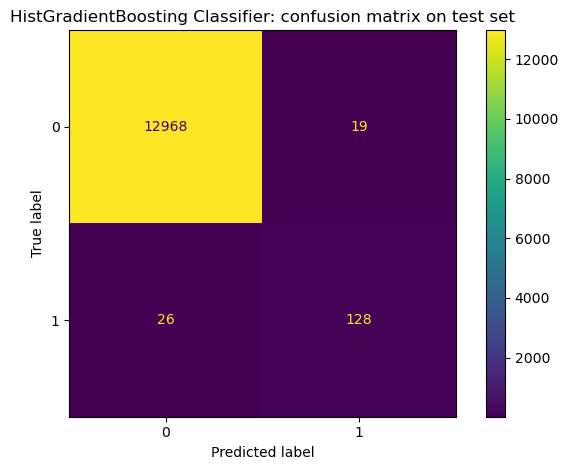

In [15]:

cm = confusion_matrix(y_test_cls, y_test_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"{best_cls_name}: confusion matrix on test set")
plt.tight_layout()
plt.show()


## 9. Neural sequence model: optional LSTM benchmark

The earlier models use engineered lags. This section adds an optional LSTM so that the project also includes a genuine sequence model. The cell is written to fail gracefully: if TensorFlow is not available in your environment, the rest of the notebook still runs.

The sequence model uses the raw selected features over the previous 12 timesteps, corresponding to the previous 2 hours at 10-minute resolution.


LSTM test metrics:
{'RMSE': np.float64(0.1460553900789444), 'MAE': 0.0964000750758662, 'R2': -0.059733087732978696}


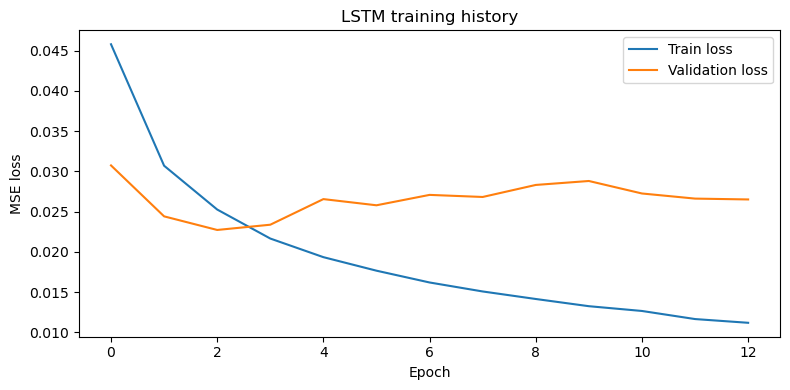

In [18]:

def make_lstm_sequences(df_features, target_series, seq_len=12):
    X_values = df_features.values
    y_values = target_series.values

    X_seq, y_seq = [], []
    for i in range(seq_len, len(df_features)):
        X_seq.append(X_values[i-seq_len:i])
        y_seq.append(y_values[i])

    return np.array(X_seq), np.array(y_seq)

try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping

    tf.random.set_seed(RANDOM_STATE)

    seq_len = 12
    seq_features = features

    # Use a scaled copy of only the original selected predictors for sequence modelling
    seq_imputer = SimpleImputer(strategy="median")
    seq_scaler = StandardScaler()

    X_train_seq_base = pd.DataFrame(seq_imputer.fit_transform(train_df[seq_features]), columns=seq_features, index=train_df.index)
    X_val_seq_base = pd.DataFrame(seq_imputer.transform(val_df[seq_features]), columns=seq_features, index=val_df.index)
    X_test_seq_base = pd.DataFrame(seq_imputer.transform(test_df[seq_features]), columns=seq_features, index=test_df.index)

    X_train_seq_base[:] = seq_scaler.fit_transform(X_train_seq_base)
    X_val_seq_base[:] = seq_scaler.transform(X_val_seq_base)
    X_test_seq_base[:] = seq_scaler.transform(X_test_seq_base)

    X_train_seq, y_train_seq = make_lstm_sequences(X_train_seq_base, y_train, seq_len=seq_len)
    X_val_seq, y_val_seq = make_lstm_sequences(X_val_seq_base, y_val, seq_len=seq_len)
    X_test_seq, y_test_seq = make_lstm_sequences(X_test_seq_base, y_test, seq_len=seq_len)

    lstm_model = Sequential([
        LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    lstm_model.compile(optimizer="adam", loss="mse")

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = lstm_model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=60,
        batch_size=128,
        verbose=0,
        callbacks=[early_stop]
    )

    y_test_pred_lstm = lstm_model.predict(X_test_seq, verbose=0).ravel()
    lstm_test_metrics = regression_metrics(pd.Series(y_test_seq), y_test_pred_lstm)

    print("LSTM test metrics:")
    print(lstm_test_metrics)

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title("LSTM training history")
    plt.legend()
    plt.tight_layout()
    plt.show()

except ImportError:
    print("TensorFlow is not installed in this environment, so the optional LSTM section was skipped.")


## 10. Exploratory phase/regime analysis

The project also aims to investigate phase changes in system behaviour. As a lightweight exploratory method, this section clusters the standardised predictor space into a small number of regimes and compares mean N$_2$O levels across them. This is not a final causal analysis, but it is useful for checking whether the plant appears to operate in distinct behavioural states.


In [16]:

phase_features = features.copy()

phase_imputer = SimpleImputer(strategy="median")
phase_scaler = StandardScaler()

X_phase = pd.DataFrame(
    phase_imputer.fit_transform(final_df[phase_features]),
    columns=phase_features,
    index=final_df.index
)
X_phase_scaled = phase_scaler.fit_transform(X_phase)

kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=20)
phase_labels = kmeans.fit_predict(X_phase_scaled)

phase_df = final_df.copy()
phase_df["phase_label"] = phase_labels

phase_summary = phase_df.groupby("phase_label")[target_col].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False)
phase_summary


,count,mean,median,std
phase_label,,,,
2,36248,0.135540,0.031250,0.240404
0,36429,0.125374,0.041782,0.222874
1,6031,0.075347,0.017245,0.210742
3,8898,0.074182,0.024884,0.121273


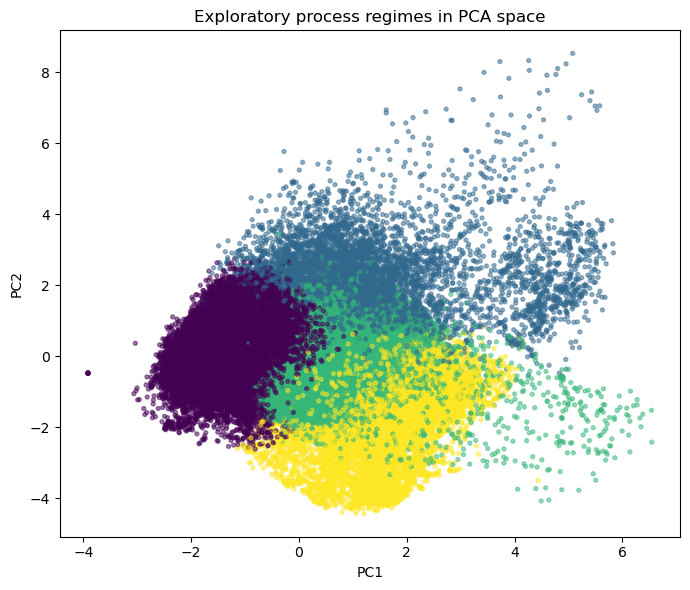

In [17]:

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_phase_pca = pca.fit_transform(X_phase_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_phase_pca[:, 0], X_phase_pca[:, 1], c=phase_labels, s=8, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Exploratory process regimes in PCA space")
plt.tight_layout()
plt.show()


## 11. Model interpretation

This final section provides simple interpretation outputs for the best tree-based regression model, if one wins. If the winning model is not tree-based, the code still runs and simply reports that no native feature importance is available.


In [19]:

best_reg_step = best_reg_model.named_steps.get("model", None)

if hasattr(best_reg_step, "feature_importances_"):
    importances = pd.Series(best_reg_step.feature_importances_, index=feature_cols).sort_values(ascending=False).head(20)

    plt.figure(figsize=(8, 6))
    importances.sort_values().plot(kind="barh")
    plt.xlabel("Feature importance")
    plt.title(f"Top features: {best_reg_name}")
    plt.tight_layout()
    plt.show()

    display(importances.to_frame("importance"))
else:
    print(f"{best_reg_name} does not expose native tree-style feature importances.")


Elastic Net does not expose native tree-style feature importances.


## 12. Final summary block

This cell prints the chosen models and key evaluation metrics so you can lift the results directly into the report once you rerun the notebook on the real data.


In [20]:

summary = {
    "Best regression model": best_reg_name,
    "Best regression test RMSE": reg_results.loc[reg_results["Model"] == best_reg_name, "Test_RMSE"].iloc[0],
    "Best regression test MAE": reg_results.loc[reg_results["Model"] == best_reg_name, "Test_MAE"].iloc[0],
    "Best regression test R2": reg_results.loc[reg_results["Model"] == best_reg_name, "Test_R2"].iloc[0],
    "Best classification model": best_cls_name,
    "Best classification test F1": cls_results.loc[cls_results["Model"] == best_cls_name, "Test_F1"].iloc[0],
    "Best classification test ROC_AUC": cls_results.loc[cls_results["Model"] == best_cls_name, "Test_ROC_AUC"].iloc[0],
    "Best classification test PR_AUC": cls_results.loc[cls_results["Model"] == best_cls_name, "Test_PR_AUC"].iloc[0],
    "Threshold used": breach_threshold,
}

pd.Series(summary)


Best regression model                                   Elastic Net
Best regression test RMSE                                  0.035955
Best regression test MAE                                   0.021091
Best regression test R2                                     0.93573
Best classification model           HistGradientBoosting Classifier
Best classification test F1                                0.850498
Best classification test ROC_AUC                           0.998739
Best classification test PR_AUC                            0.951813
Threshold used                                               0.6832
dtype: object